# MBG YouTube Sentiment Analysis & Text Mining

**Author: Brian Naufal**

End-to-end **Text Mining + NLP + Machine Learning + Deep Learning** project untuk menganalisis komentar YouTube terkait Makan Bergizi Gratis (MBG).

### Portfolio objective
Notebook ini dirancang untuk menunjukkan workflow yang dapat dipertanggungjawabkan:

**Data quality → duplicate-leakage control → reviewed validation → preprocessing → EDA/text mining → stratified split → class-imbalance-aware modeling → Optuna tuning → evaluation → error analysis → explainability → 3-class benchmark → exportable results**

> Dataset YouTube merupakan sampel berbasis platform. Hasil project menggambarkan data yang dikumpulkan, bukan opini seluruh populasi.

## Cara membaca notebook ini

Notebook ini bukan hanya kumpulan kode untuk melatih model. Setiap bagian menjawab satu pertanyaan analitis:

**Data yang dipakai seperti apa? → Apakah datanya bersih? → Bagaimana teks diproses? → Pola apa yang terlihat? → Bagaimana sentimen diprediksi? → Seberapa baik modelnya? → Kenapa model bisa salah? → Apa yang bisa dijelaskan dari model?**

### Alur end-to-end

`YouTube comments → Data Quality → Deduplication → Label Review → Text Preprocessing → EDA/Text Mining → Binary Modeling → Hyperparameter Tuning → Evaluation → Error Analysis → Explainability → 3-Class Benchmark → Final Summary`

### Cara membaca output

- **Count / distribution** menjelaskan kondisi dataset.
- **Metric model** menjelaskan performa prediksi. Karena dataset binary sangat tidak seimbang, Accuracy tidak boleh dibaca sendirian.
- **Confusion matrix / error analysis** menjelaskan jenis kesalahan model.
- **Top terms / coefficients** menjelaskan kata yang paling terkait dengan prediksi model.
- **3-class benchmark** menunjukkan performa ketika `neutral` dipertahankan sebagai kelas terpisah.

> **Catatan:** hasil notebook berlaku untuk dataset YouTube yang dikumpulkan dalam project ini. Hasil tersebut bukan pengukuran langsung terhadap seluruh opini masyarakat.


## 1. Data Collection & Labeling Methodology

### Data lineage

**YouTube comments → raw CSV → cleaning/quality checks → labeled dataset → model-ready deduplicated corpus → train/validation/test**

Repository menyimpan beberapa tahap data:
- `data/mbg_comments_raw.csv`: raw collection
- `data/mbg_comments_clean.csv`: hasil cleaning dan quality checks
- `data/mbg_comments_to_label.csv`: sample untuk proses labeling manual
- `data/mbg_comments_labeled.csv`: current portfolio dataset yang digunakan notebook

### Label methodology

Dataset portfolio tetap menggunakan **AI-assisted semantic labeling** untuk analisis dataset dan benchmark 3-class:
- `positive`
- `negative`
- `neutral`

Untuk **binary sentiment task dan validation review**, project menggunakan hanya:
- `positive`
- `negative`

Pada validation review, komentar yang sebelumnya berada pada label `neutral` dipetakan menjadi `negative` sesuai aturan anotasi yang direview oleh project owner. Ini adalah **human-reviewed AI-assisted annotation**, bukan independent gold-standard annotation.

Notebook membedakan:
1. **dataset label space** = 3-class (`positive/negative/neutral`);
2. **binary modeling label space** = `positive/negative`;
3. **validation review label space** = `positive/negative`.

> Exact AI provider/prompt tidak diklaim di notebook karena informasi tersebut tidak terdokumentasi secara eksplisit di repository.

### Tujuan bagian ini

Bagian ini menjawab **"Dataset ini berasal dari mana, bagaimana labelnya dibuat, dan apa yang sebenarnya dimodelkan?"**

### Input

Dataset utama yang digunakan notebook adalah `data/mbg_comments_labeled.csv`. Setiap baris mewakili satu komentar YouTube beserta informasi waktu dan label sentimennya.

### Dua ruang label

Dataset utama mempertahankan **3 kelas**:

- `positive`
- `negative`
- `neutral`

Untuk **binary sentiment task**, model hanya memisahkan:

- `positive`
- `negative`

Komentar `neutral` tidak dimasukkan ke binary modeling. Dengan demikian binary classifier benar-benar mempelajari batas **positif vs negatif**, bukan memaksa semua komentar menjadi salah satu dari dua kelas.

Untuk validation review, project menggunakan ruang label binary `positive/negative` sesuai aturan anotasi project. Karena itu, hasil validation harus dibaca sebagai **review terhadap aturan binary tersebut**, bukan sebagai independent gold-standard annotation study.

### Output yang diharapkan

Setelah bagian ini, pembaca seharusnya memahami:

1. sumber data adalah komentar YouTube;
2. dataset utama mempunyai 3 label;
3. binary model menggunakan 2 label;
4. 3-class benchmark akan dievaluasi secara terpisah.


In [1]:
import os
import re
import html
import json
import random
import warnings
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    cohen_kappa_score,
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TF_AVAILABLE = False
OPTUNA_AVAILABLE = False

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, GRU, Dense, Dropout
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.callbacks import EarlyStopping
    TF_AVAILABLE = True
except ImportError:
    tf = None

try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    optuna = None

if TF_AVAILABLE:
    tf.keras.utils.set_random_seed(SEED)

if OPTUNA_AVAILABLE:
    optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "data" / "mbg_comments_labeled.csv").exists():
        PROJECT_ROOT = candidate
        break

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "mbg_comments_labeled.csv"

print("Project root :", PROJECT_ROOT)
print("Dataset path :", DATA_PATH)
print("TensorFlow   :", TF_AVAILABLE)
print("Optuna       :", OPTUNA_AVAILABLE)



I0000 00:00:1790175360.285662    2266 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790175360.286263    2266 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1790175361.840647    2266 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790175361.841019    2266 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Project root : /home/runner/work/mbg-youtube-sentiment-analysis/mbg-youtube-sentiment-analysis
Dataset path : /home/runner/work/mbg-youtube-sentiment-analysis/mbg-youtube-sentiment-analysis/data/mbg_comments_labeled.csv
TensorFlow   : True
Optuna       : True


In [2]:
# Load and validate the portfolio dataset.
required_columns = ["row_id", "comment", "comment_clean", "published_at", "sentiment"]

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset tidak ditemukan: {DATA_PATH}"
    )

YT_comments = pd.read_csv(DATA_PATH)

missing_required = [c for c in required_columns if c not in YT_comments.columns]
if missing_required:
    raise ValueError(f"Kolom wajib tidak ditemukan: {missing_required}")

YT_comments["published_at"] = pd.to_datetime(
    YT_comments["published_at"],
    errors="coerce",
    utc=True
)

YT_comments["sentiment"] = (
    YT_comments["sentiment"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Main dataset label space: retained 3-class for EDA and the dedicated 3-class benchmark.
VALID_LABELS = ["positive", "negative", "neutral"]

# Validation / binary-review label space: neutral is mapped to negative per reviewed project rule.
VALIDATION_LABELS = ["positive", "negative"]
VALIDATION_BINARY_MAP = {
    "positive": "positive",
    "negative": "negative",
    "neutral": "negative",
}

invalid_labels = sorted(
    set(YT_comments["sentiment"].dropna().unique()) - set(VALID_LABELS)
)
if invalid_labels:
    raise ValueError(f"Unexpected sentiment labels: {invalid_labels}")

print(f"Rows          : {len(YT_comments):,}")
print(f"Columns       : {len(YT_comments.columns)}")
print(f"Missing dates : {YT_comments['published_at'].isna().sum():,}")
print(f"Duplicate row_id: {YT_comments['row_id'].duplicated().sum():,}")
print(f"Duplicate exact comment: {YT_comments['comment'].duplicated().sum():,}")
print("\nSentiment distribution:")
print(YT_comments["sentiment"].value_counts())


Rows          : 12,000
Columns       : 5
Missing dates : 0
Duplicate row_id: 0
Duplicate exact comment: 453

Sentiment distribution:
sentiment
neutral     8900
negative    2880
positive     220
Name: count, dtype: Int64


## 2. Data Quality & Duplicate Leakage Control

Duplicate text is preserved in the raw dataset for descriptive analysis, but **must not be allowed to leak across model splits**.

Strategy:
1. Normalize raw comment text into a deterministic `dedup_key`.
2. Remove invalid/empty comments.
3. Detect duplicate groups with conflicting sentiment labels.
4. Remove conflicting duplicate groups from modeling rather than arbitrarily choosing a label.
5. Deduplicate by `dedup_key` **before** train/validation/test splitting.
6. Assert that no duplicate `dedup_key` appears in more than one split.

This means the EDA can describe the collected corpus while the ML corpus is protected from repeated-text leakage.

### Tujuan bagian ini

Bagian ini menjawab **"Apakah teks yang sama dapat muncul berkali-kali dan membuat performa model terlihat lebih bagus dari kondisi sebenarnya?"**

Masalah yang dikontrol adalah **duplicate leakage**. Jika komentar yang sama masuk ke train dan test, model dapat terlihat akurat hanya karena pernah melihat teks yang sama.

### Apa yang dilakukan kode

1. Membuat `dedup_key` dari komentar yang dinormalisasi.
2. Menghitung komentar kosong dan duplikat.
3. Mencari kelompok komentar yang sama tetapi mempunyai label berbeda.
4. Menghapus kelompok konflik dari corpus modeling.
5. Menyisakan satu representasi untuk setiap `dedup_key`.
6. Baru setelah itu data digunakan untuk split train/validation/test.

### Cara membaca hasil

- `raw_rows` = jumlah baris awal.
- `duplicate_exact_comment` = duplikat persis.
- `duplicate_normalized_comment` = duplikat setelah normalisasi.
- `conflicting_duplicate_groups` = kelompok teks dengan label berbeda.
- `model_rows_after_dedup` = jumlah data yang benar-benar tersedia untuk modeling.

Angka terakhir adalah ukuran penting untuk mengikuti transformasi dari raw corpus menjadi ML corpus.


In [3]:
def normalize_dedup_text(text):
    if pd.isna(text):
        return ""
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text, flags=re.I)
    text = re.sub(r"@[A-Za-z0-9_]+", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

YT_comments["dedup_key"] = YT_comments["comment"].map(normalize_dedup_text)

quality = {
    "raw_rows": int(len(YT_comments)),
    "missing_comment": int(YT_comments["comment"].isna().sum()),
    "empty_comment": int(YT_comments["dedup_key"].eq("").sum()),
    "duplicate_exact_comment": int(YT_comments["comment"].duplicated().sum()),
    "duplicate_normalized_comment": int(YT_comments["dedup_key"].duplicated().sum()),
    "invalid_published_at": int(YT_comments["published_at"].isna().sum()),
}

valid_for_model = YT_comments[
    YT_comments["dedup_key"].ne("")
    & YT_comments["sentiment"].isin(VALID_LABELS)
].copy()

label_counts_per_group = valid_for_model.groupby("dedup_key")["sentiment"].nunique()
conflicting_groups = set(label_counts_per_group[label_counts_per_group > 1].index)
conflicting_row_count = int(
    valid_for_model["dedup_key"].isin(conflicting_groups).sum()
)

if conflicting_groups:
    valid_for_model = valid_for_model[
        ~valid_for_model["dedup_key"].isin(conflicting_groups)
    ].copy()

model_df = valid_for_model.drop_duplicates("dedup_key", keep="first").copy()

quality["conflicting_duplicate_groups"] = int(len(conflicting_groups))
quality["rows_removed_conflicting_groups"] = conflicting_row_count
quality["rows_removed_duplicate_text"] = int(len(valid_for_model) - len(model_df))
quality["model_rows_after_dedup"] = int(len(model_df))

quality_df = pd.DataFrame({
    "metric": list(quality.keys()),
    "value": list(quality.values())
})
display(quality_df)
quality_df.to_csv(RESULTS_DIR / "data_quality_profile.csv", index=False)

print(f"\nModel corpus: {len(model_df):,} unique comments after leakage control.")



,metric,value
0,raw_rows,12000
1,missing_comment,0
2,empty_comment,443
3,duplicate_exact_comment,453
4,duplicate_normalized_comment,1047
5,invalid_published_at,0
6,conflicting_duplicate_groups,18
7,rows_removed_conflicting_groups,159
8,rows_removed_duplicate_text,464
9,model_rows_after_dedup,10934



Model corpus: 10,934 unique comments after leakage control.


## 3. Human Review of Binary Sentiment Labels

A validation sample is used to review the AI-assisted labels under the project's binary sentiment rule.

The exported file uses only:
- `validation_id`
- `row_id`
- `comment`
- `published_at`
- `human_label`
- `human_notes`

The validation label space is **binary**:
- `positive`
- `negative`

Any `neutral` label from the original 3-class dataset is treated as `negative` for this binary review, following the project owner's reviewed annotation rule.

Because the labels originated from an AI-assisted draft and were then reviewed, the result is described as **human-reviewed AI-assisted annotation**, not as an independent gold-standard benchmark.

### Tujuan bagian ini

Bagian ini menjawab **"Seberapa konsisten label binary pada sample yang direview?"**

Validation sample dibandingkan menggunakan ruang label:

`positive` vs `negative`

### Apa yang dilakukan kode

Kode:

1. membaca sample validation;
2. memastikan label review valid;
3. menyelaraskan label dengan aturan binary validation;
4. membandingkan label referensi dengan `human_label`;
5. menghitung Accuracy, Macro F1, dan Cohen's Kappa.

### Cara membaca hasil

- **Accuracy** = proporsi label yang sama.
- **Macro F1** = rata-rata F1 antar kelas.
- **Cohen's Kappa** = ukuran agreement yang mempertimbangkan agreement karena kebetulan.

> Karena dataset utama menggunakan AI-assisted labels dan sample ini merupakan **human-reviewed AI-assisted annotation**, hasilnya bukan independent gold-standard annotation study.


Human-review file     : /home/runner/work/mbg-youtube-sentiment-analysis/mbg-youtube-sentiment-analysis/results/human_validation_sample_for_annotation.csv
Rows prepared         : 300
Binary labels filled  : 300


,rows_scored,review_consistency_accuracy,review_consistency_macro_f1,review_consistency_cohen_kappa
0,300,0.78,0.698465,0.424419


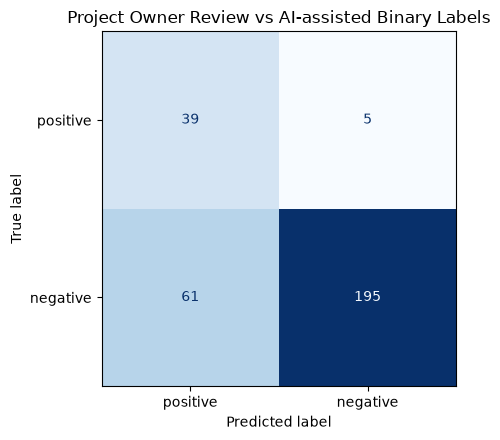

Human review status: COMPLETED_REVIEWED


In [4]:
HUMAN_SAMPLE_PATH = RESULTS_DIR / "human_validation_sample_for_annotation.csv"

# Create a reusable binary review sample only when the file does not already exist.
# Positive is capped at 100 rows; the remaining rows are sampled from negative + neutral
# and then reviewed under the binary rule neutral -> negative.
if not HUMAN_SAMPLE_PATH.exists():
    binary_source = model_df.copy()
    binary_source["validation_ai_label"] = binary_source["sentiment"].map(
        VALIDATION_BINARY_MAP
    )

    positive_group = binary_source[binary_source["validation_ai_label"] == "positive"]
    negative_group = binary_source[binary_source["validation_ai_label"] == "negative"]

    n_positive = min(100, len(positive_group))
    n_negative = min(200, len(negative_group))

    parts = []
    if n_positive:
        parts.append(positive_group.sample(n=n_positive, random_state=SEED))
    if n_negative:
        parts.append(negative_group.sample(n=n_negative, random_state=SEED))

    human_sample = (
        pd.concat(parts, ignore_index=True)
        if parts
        else binary_source.head(0).copy()
    )
    human_sample = human_sample.sample(frac=1, random_state=SEED).reset_index(drop=True)
    human_sample.insert(0, "validation_id", np.arange(1, len(human_sample) + 1))
    human_sample = human_sample[["validation_id", "row_id", "comment", "published_at"]]
    human_sample["human_label"] = ""
    human_sample["human_notes"] = ""
    human_sample.to_csv(HUMAN_SAMPLE_PATH, index=False, encoding="utf-8-sig")

human_validation = pd.read_csv(HUMAN_SAMPLE_PATH)
human_validation["human_label"] = (
    human_validation["human_label"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

filled = human_validation["human_label"].isin(VALIDATION_LABELS)
print(f"Human-review file     : {HUMAN_SAMPLE_PATH}")
print(f"Rows prepared         : {len(human_validation):,}")
print(f"Binary labels filled  : {int(filled.sum()):,}")

if filled.sum() == 0:
    human_validation_status = "PENDING"
    print("Status: PENDING — isi kolom human_label sebelum menghitung review consistency.")
else:
    scored = human_validation.loc[filled, ["row_id", "human_label"]].merge(
        model_df[["row_id", "sentiment"]],
        on="row_id",
        how="inner"
    )
    scored["ai_binary_label"] = scored["sentiment"].map(VALIDATION_BINARY_MAP)

    y_review = scored["human_label"]
    y_ai_binary = scored["ai_binary_label"]
    human_validation_status = "COMPLETED_REVIEWED"

    review_metrics = pd.DataFrame([{
        "rows_scored": len(scored),
        "review_consistency_accuracy": accuracy_score(y_review, y_ai_binary),
        "review_consistency_macro_f1": f1_score(
            y_review, y_ai_binary, average="macro", zero_division=0
        ),
        "review_consistency_cohen_kappa": cohen_kappa_score(
            y_review, y_ai_binary, labels=VALIDATION_LABELS
        ),
    }])
    display(review_metrics)
    review_metrics.to_csv(
        RESULTS_DIR / "human_validation_scoring.csv",
        index=False
    )

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ConfusionMatrixDisplay.from_predictions(
        y_review,
        y_ai_binary,
        labels=VALIDATION_LABELS,
        display_labels=VALIDATION_LABELS,
        ax=ax,
        cmap="Blues",
        colorbar=False
    )
    ax.set_title("Project Owner Review vs AI-assisted Binary Labels")
    plt.tight_layout()
    plt.show()

print("Human review status:", human_validation_status)


## 4. Text Preprocessing

Preprocessing is designed for Indonesian YouTube-style text while preserving sentiment-bearing negations.

Steps:
1. HTML/entity normalization
2. URL / mention removal
3. hashtag symbol removal while keeping the word
4. Unicode normalization
5. lowercasing
6. repeated-character normalization
7. slang normalization
8. Indonesian stopword removal
9. negation preservation
10. optional Sastrawi stemming

Stemming remains disabled by default for faster portfolio execution. The preprocessing output is calculated from the current dataset rather than copied from previous runs.

### Tujuan bagian ini

Bagian ini mengubah komentar mentah menjadi teks yang lebih konsisten untuk algoritma NLP.

### Apa yang dilakukan kode

Preprocessing mengurangi noise seperti URL, mention, karakter tertentu, dan spasi berlebih, tetapi tetap mempertahankan informasi yang penting untuk sentimen, termasuk **kata negasi**.

Alurnya:

**Input:** komentar asli  
**Proses:** normalisasi + cleaning + penanganan pola teks  
**Output:** `text_preprocessed`

Kolom `text_preprocessed` inilah yang kemudian digunakan oleh model NLP.

### Cara membaca hasil

Tujuan preprocessing bukan "menghapus sebanyak mungkin kata". Tujuannya adalah **mengurangi noise tanpa menghilangkan sinyal sentimen**.


In [5]:
NEGATION_WORDS = {
    "tidak", "tak", "bukan", "jangan", "belum",
    "gak", "nggak", "ga", "ngga", "tdk", "kurang"
}

STOPWORDS = {
    "yang", "dan", "di", "ke", "dari", "untuk", "pada", "dengan",
    "ini", "itu", "ada", "akan", "atau", "juga", "saja", "sudah",
    "sangat", "lebih", "dalam", "karena", "kalau", "kalo", "jadi",
    "buat", "bagi", "oleh", "sebagai", "dapat", "bisa", "mereka",
    "kita", "kami", "saya", "aku", "anda", "dia", "nya", "lah",
    "pun", "kok", "tuh", "mah", "kan", "aja"
} - NEGATION_WORDS

SLANG = {
    "gk": "gak", "ga": "gak", "nggak": "gak", "ngga": "gak",
    "tdk": "tidak", "bkn": "bukan", "jgn": "jangan", "krn": "karena",
    "knp": "kenapa", "knpa": "kenapa", "tp": "tapi", "tpi": "tapi",
    "bgt": "banget", "bgd": "banget", "gt": "gitu", "jg": "juga",
    "skg": "sekarang", "udh": "sudah", "sdh": "sudah", "dah": "sudah",
    "yg": "yang", "dgn": "dengan", "lg": "lagi", "tau": "tahu",
    "smua": "semua", "org": "orang", "dpt": "dapat", "msh": "masih",
    "utk": "untuk", "lbh": "lebih", "dri": "dari", "dr": "dari",
    "kyk": "kayak", "mkn": "makan", "mslh": "masalah", "bnyk": "banyak",
    "mlh": "malah", "nnti": "nanti", "cuma": "hanya", "abis": "habis",
    "bener": "benar", "emg": "memang", "emang": "memang"
}

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    SASTRAWI_AVAILABLE = True
    stemmer = StemmerFactory().create_stemmer()
except Exception:
    SASTRAWI_AVAILABLE = False
    stemmer = None

USE_STEMMING = False

def clean_for_nlp(text):
    text = "" if pd.isna(text) else str(text)
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text, flags=re.I)
    text = re.sub(r"@[A-Za-z0-9_]+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = text.lower()
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = [SLANG.get(tok, tok) for tok in text.split()]
    tokens = [tok for tok in tokens if tok not in STOPWORDS and len(tok) > 1]

    if not tokens:
        return ""

    text = " ".join(tokens)
    if USE_STEMMING and SASTRAWI_AVAILABLE:
        text = stemmer.stem(text)

    return re.sub(r"\s+", " ", text).strip()

YT_comments["text_source"] = (
    YT_comments["comment_clean"]
    .fillna(YT_comments["comment"])
)

YT_comments["text_preprocessed"] = YT_comments["text_source"].map(clean_for_nlp)
model_df["text_preprocessed"] = (
    model_df["comment_clean"]
    .fillna(model_df["comment"])
    .map(clean_for_nlp)
)

raw_empty = int(YT_comments["text_preprocessed"].eq("").sum())
model_empty = int(model_df["text_preprocessed"].eq("").sum())

print("Sastrawi available :", SASTRAWI_AVAILABLE)
print("Stemming enabled   :", USE_STEMMING)
print("Raw empty after preprocessing   :", raw_empty)
print("Model empty after preprocessing :", model_empty)

display(
    YT_comments[["comment", "text_preprocessed"]]
    .sample(min(10, len(YT_comments)), random_state=SEED)
)



Sastrawi available : True
Stemming enabled   : False
Raw empty after preprocessing   : 549
Model empty after preprocessing : 36


,comment,text_preprocessed
1935,Banggg kalo ngak gitu ngak bisa korupsi lahhhh...,bangg ngak gitu ngak korupsi lahh piye too kar...
6494,Saya setuju kalau mbg dihentikan diganti sj d...,setuju mbg dihentikan diganti sj dengsn harga ...
1720,Rampok berkedok mbg. \nSangat kejam,rampok berkedok mbg kejam
9120,Makin lama makin sadis pemerintah ke rakyat..\...,makin lama makin sadis pemerintah rakyat thun ...
360,Ini sekarang bukan makanan bergizi gratis tp m...,sekarang bukan makanan bergizi gratis tapi mak...
9663,Entah ini ulah yg mau menjelekkan program mbg ...,entah ulah mau menjelekkan program mbg memang ...
5277,Hebat hebat presiden kita mantap betul ya woi ...,hebat hebat presiden mantap betul ya woi masya...
8546,Aku Uda dpt😊,uda
2221,itu tebu bukan bambyu😭😭,tebu bukan bambyu
4617,"Mantap ibu ini sangat cerdas,",mantap ibu cerdas


## 5. Exploratory Text Mining

EDA uses the full collected dataset to answer descriptive questions:
- sentiment composition
- comment length
- daily discussion volume
- sentiment trend
- top vocabulary

The EDA is intentionally separated from the modeling corpus so duplicate-leakage handling does not distort the descriptive picture of the collected comments.

### Tujuan bagian ini

Bagian ini melakukan **Exploratory Data Analysis (EDA) khusus teks** sebelum model dibangun.

Pertanyaan yang ingin dijawab:

- Seberapa panjang komentar?
- Sentimen mana yang paling banyak?
- Seberapa tidak seimbang kelasnya?
- Kata/pola bahasa apa yang sering muncul?
- Apakah banyak komentar sangat pendek atau berpotensi noise?

### Apa yang dilakukan kode

Kode menghitung statistik teks, distribusi label, frekuensi kata, dan visualisasi.

### Mengapa bagian ini penting?

EDA memberi konteks sebelum modeling. Jika satu kelas jauh lebih dominan, Accuracy dapat terlihat tinggi walaupun model kurang baik dalam mengenali kelas minoritas. Karena itu hasil EDA menjadi dasar penggunaan **Balanced Accuracy, Macro F1, dan PR-AUC** pada tahap evaluasi.


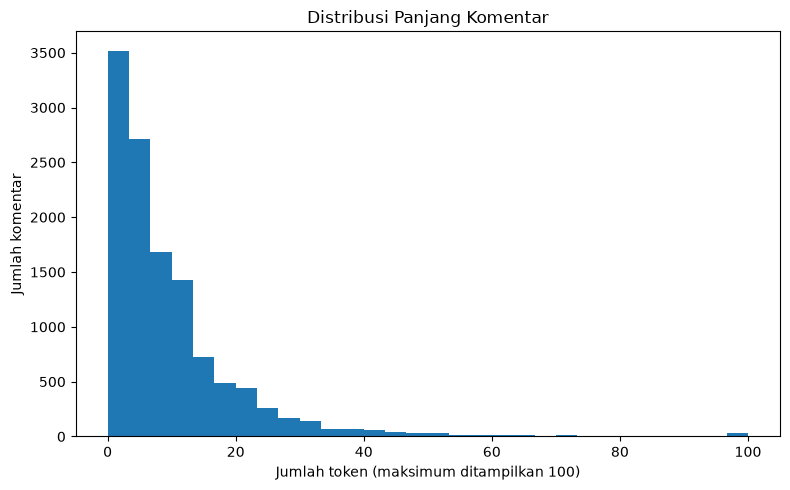

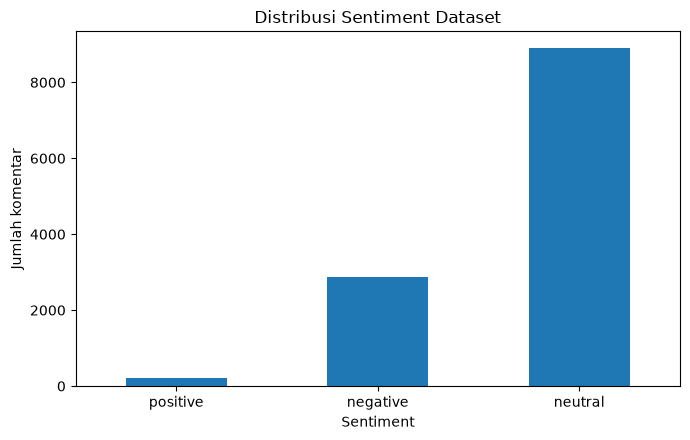

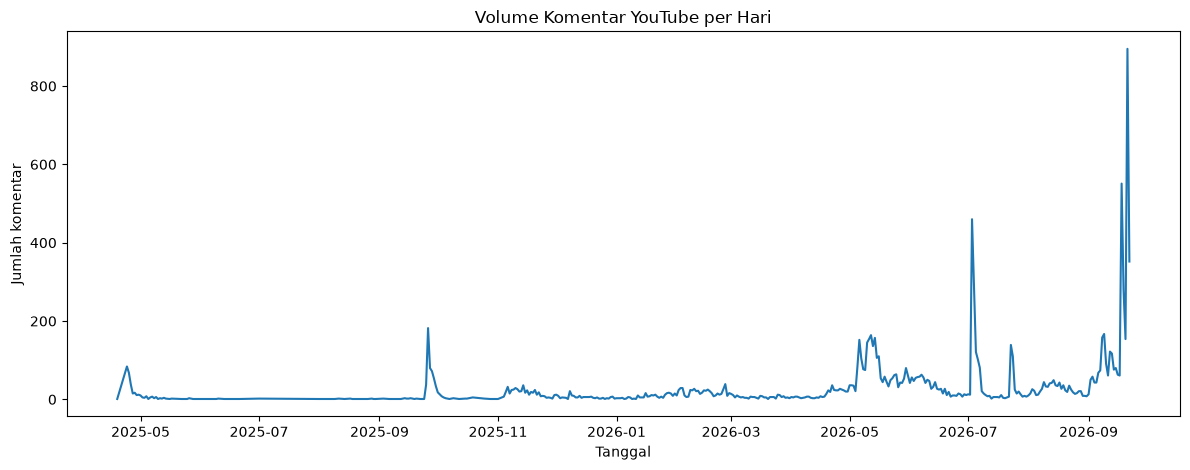

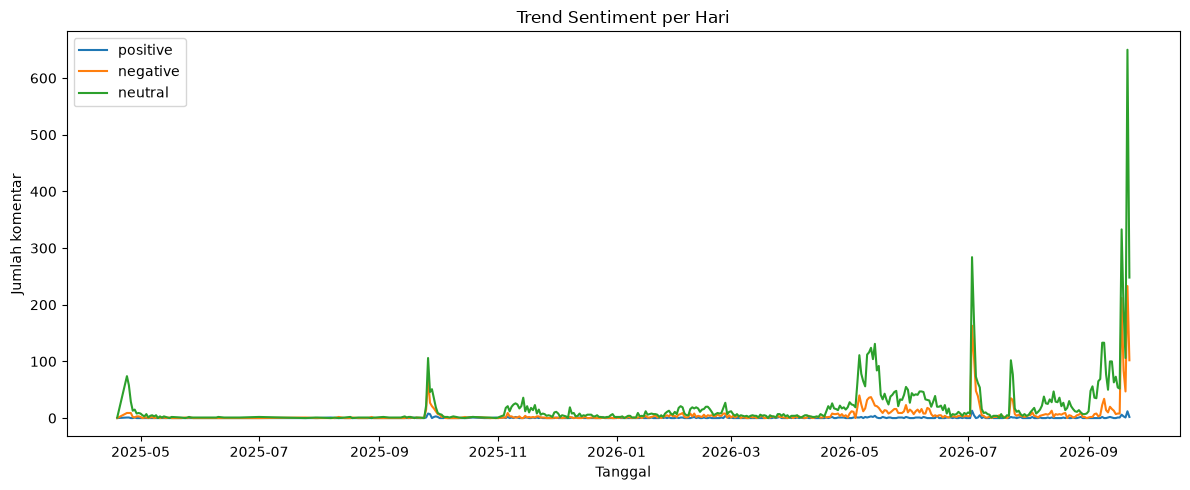

,word,count
0,mbg,5164
1,gak,1678
2,tidak,1218
3,makan,1114
4,anak,1038
5,rakyat,996
6,sekolah,935
7,indonesia,917
8,orang,867
9,tapi,848


In [6]:
YT_comments["comment_length"] = YT_comments["text_preprocessed"].str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(YT_comments["comment_length"].dropna().clip(upper=100), bins=30)
ax.set_title("Distribusi Panjang Komentar")
ax.set_xlabel("Jumlah token (maksimum ditampilkan 100)")
ax.set_ylabel("Jumlah komentar")
plt.tight_layout()
plt.show()

sentiment_counts = YT_comments["sentiment"].value_counts().reindex(VALID_LABELS, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4.5))
sentiment_counts.plot(kind="bar", ax=ax)
ax.set_title("Distribusi Sentiment Dataset")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Jumlah komentar")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

daily_volume = (
    YT_comments.dropna(subset=["published_at"])
    .assign(date=lambda d: d["published_at"].dt.date)
    .groupby("date")
    .size()
)

fig, ax = plt.subplots(figsize=(12, 4.8))
daily_volume.plot(ax=ax)
ax.set_title("Volume Komentar YouTube per Hari")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Jumlah komentar")
plt.tight_layout()
plt.show()

sentiment_trend = (
    YT_comments.dropna(subset=["published_at"])
    .assign(date=lambda d: d["published_at"].dt.date)
    .pivot_table(index="date", columns="sentiment", values="comment", aggfunc="count", fill_value=0)
    .reindex(columns=VALID_LABELS, fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))
for label in VALID_LABELS:
    ax.plot(sentiment_trend.index, sentiment_trend[label], label=label)
ax.set_title("Trend Sentiment per Hari")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Jumlah komentar")
ax.legend()
plt.tight_layout()
plt.show()

all_words = " ".join(YT_comments["text_preprocessed"].dropna())
top_words_overall = pd.DataFrame(
    Counter(all_words.split()).most_common(20),
    columns=["word", "count"]
)
display(top_words_overall)



In [7]:
dominant_label = sentiment_counts.idxmax()
peak_date = daily_volume.idxmax() if len(daily_volume) else None

print("=== EDA DATA-DRIVEN SUMMARY ===")
print(f"Total collected comments : {len(YT_comments):,}")
print(f"Dominant sentiment       : {dominant_label} ({sentiment_counts[dominant_label] / len(YT_comments) * 100:.2f}%)")
if peak_date is not None:
    print(f"Peak discussion date     : {peak_date} ({int(daily_volume.loc[peak_date]):,} comments)")
print(f"Unique modeling comments : {len(model_df):,}")
print(f"Normalized duplicates removed before modeling: {len(valid_for_model) - len(model_df):,}")

if len(top_words_overall):
    print("\nTop five words:")
    for _, row in top_words_overall.head(5).iterrows():
        print(f"- {row['word']}: {int(row['count']):,}")



=== EDA DATA-DRIVEN SUMMARY ===
Total collected comments : 12,000
Dominant sentiment       : neutral (74.17%)
Peak discussion date     : 2026-09-21 (895 comments)
Unique modeling comments : 10,934
Normalized duplicates removed before modeling: 464

Top five words:
- mbg: 5,164
- gak: 1,678
- tidak: 1,218
- makan: 1,114
- anak: 1,038


## 6. Binary Classification Setup: Positive vs Negative

### Why is neutral excluded here?

The binary task answers a narrower modeling question:

**Can a model separate clearly positive comments from clearly negative comments?**

Neutral is therefore excluded from this specific binary classifier, not treated as useless data. Because neutral is retained in the EDA and a separate **3-class classifier** is built later, the exclusion is methodological rather than an attempt to discard the majority class.

The binary dataset remains strongly imbalanced, so **class weighting, Balanced Accuracy, Macro F1, per-class metrics, and PR-AUC** are reported in addition to accuracy.

### Tujuan bagian ini

Bagian ini menentukan dataset yang benar-benar masuk ke **binary classification**.

Pertanyaan modelnya adalah:

> **"Dari komentar yang sudah berlabel positive atau negative, seberapa baik model membedakan kedua kelas tersebut?"**

### Filtering

Sebuah baris hanya masuk jika:

1. label termasuk `positive` atau `negative`;
2. `text_preprocessed` tidak kosong.

Komentar `neutral` tetap ada di dataset utama, tetapi tidak digunakan dalam binary task.

### Split data

Data kemudian dibagi menggunakan **stratification** agar proporsi kelas tetap relatif sama pada train, validation, dan test.

### Output penting

- jumlah `binary_df`;
- ukuran train;
- ukuran validation;
- ukuran test;
- proporsi positive pada setiap split.

Jika proporsi kelas antar split sangat berbeda, evaluasi bisa menjadi kurang representatif.


In [8]:
binary_df = model_df[
    model_df["sentiment"].isin(["positive", "negative"])
    & model_df["text_preprocessed"].ne("")
].copy()

# Split at the row level after duplicate removal.
train_val_df, test_df = train_test_split(
    binary_df,
    test_size=0.15,
    random_state=SEED,
    stratify=binary_df["sentiment"]
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1764705882,
    random_state=SEED,
    stratify=train_val_df["sentiment"]
)

def assert_no_duplicate_overlap(*dfs):
    key_sets = [set(df["dedup_key"]) for df in dfs]
    for i in range(len(key_sets)):
        for j in range(i + 1, len(key_sets)):
            overlap = key_sets[i] & key_sets[j]
            assert not overlap, (
                f"Duplicate leakage detected between split {i} and {j}: "
                f"{len(overlap)} groups"
            )

assert_no_duplicate_overlap(train_df, val_df, test_df)

X_train = train_df["text_preprocessed"].reset_index(drop=True)
X_val = val_df["text_preprocessed"].reset_index(drop=True)
X_test = test_df["text_preprocessed"].reset_index(drop=True)
y_train = (train_df["sentiment"] == "positive").astype(int).reset_index(drop=True)
y_val = (val_df["sentiment"] == "positive").astype(int).reset_index(drop=True)
y_test = (test_df["sentiment"] == "positive").astype(int).reset_index(drop=True)

print("Duplicate-key leakage assertion: PASSED")
print(f"Train / validation / test rows: {len(train_df):,} / {len(val_df):,} / {len(test_df):,}")
print(f"Train positive share: {y_train.mean() * 100:.2f}%")
print(f"Validation positive share: {y_val.mean() * 100:.2f}%")
print(f"Test positive share: {y_test.mean() * 100:.2f}%")



Duplicate-key leakage assertion: PASSED
Train / validation / test rows: 2,073 / 445 / 445
Train positive share: 6.66%
Validation positive share: 6.74%
Test positive share: 6.74%


In [9]:
# Shared evaluation helpers.
def select_threshold(y_true, proba, grid=None):
    if grid is None:
        grid = np.linspace(0.10, 0.90, 81)

    rows = []
    for threshold in grid:
        pred = (proba >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "macro_f1": f1_score(y_true, pred, average="macro", zero_division=0),
            "positive_f1": f1_score(y_true, pred, pos_label=1, zero_division=0),
        })

    threshold_df = pd.DataFrame(rows)
    best = threshold_df.loc[threshold_df["macro_f1"].idxmax()]
    return float(best["threshold"]), threshold_df

def binary_metrics(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision_positive": precision_score(y_true, pred, pos_label=1, zero_division=0),
        "recall_positive": recall_score(y_true, pred, pos_label=1, zero_division=0),
        "f1_positive": f1_score(y_true, pred, pos_label=1, zero_division=0),
        "macro_f1": f1_score(y_true, pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, pred, average="weighted", zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
    }

classes_binary = np.array([0, 1])
cw_values = compute_class_weight(
    class_weight="balanced",
    classes=classes_binary,
    y=y_train
)
CLASS_WEIGHTS = {int(c): float(w) for c, w in zip(classes_binary, cw_values)}
print("Class weights:", CLASS_WEIGHTS)



Class weights: {0: 0.5356589147286822, 1: 7.510869565217392}


## 7. TF-IDF + Logistic Regression Baseline

The classical baseline is trained first because:
- TF-IDF is highly interpretable,
- Logistic Regression supports class weighting directly,
- it provides a stable benchmark before comparing deep learning,
- and its coefficients can be inspected for explainability.

The vectorizer is **fit on training data only**.

### Tujuan bagian ini

TF-IDF + Logistic Regression digunakan sebagai **baseline machine learning**. Baseline memberi titik pembanding sederhana sebelum menggunakan deep learning.

### Apa yang dilakukan kode

**TF-IDF** mengubah teks menjadi angka berdasarkan seberapa informatif sebuah kata dalam suatu komentar dibandingkan corpus.

Kemudian **Logistic Regression** mempelajari hubungan antara fitur TF-IDF dan label positive/negative.

### Hal penting

Vectorizer di-fit pada **training data** saja. Test data tidak boleh ikut membentuk vocabulary atau bobot fitur karena hal tersebut dapat menimbulkan data leakage.

### Output

Bagian ini menghasilkan probability prediction dan metrik baseline yang nanti dibandingkan dengan BiLSTM dan BiGRU.

### Cara membaca hasil

Fokuskan perhatian pada:

- Balanced Accuracy
- Macro F1
- Positive Recall / F1
- PR-AUC

karena kelas positive jauh lebih sedikit dibanding negative.


In [10]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    max_features=30000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

tfidf_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=SEED
)

tfidf_model.fit(X_train_tfidf, y_train)

tfidf_val_proba = tfidf_model.predict_proba(X_val_tfidf)[:, 1]
tfidf_threshold, tfidf_threshold_df = select_threshold(y_val, tfidf_val_proba)

tfidf_test_proba = tfidf_model.predict_proba(X_test_tfidf)[:, 1]
tfidf_test_metrics = binary_metrics(
    y_test,
    tfidf_test_proba,
    threshold=tfidf_threshold
)
tfidf_val_metrics = binary_metrics(
    y_val,
    tfidf_val_proba,
    threshold=tfidf_threshold
)

print(f"Selected threshold from validation set: {tfidf_threshold:.3f}")
print("\nValidation metrics:")
display(pd.DataFrame([tfidf_val_metrics]))
print("\nTest metrics:")
display(pd.DataFrame([tfidf_test_metrics]))

tfidf_test_pred = (tfidf_test_proba >= tfidf_threshold).astype(int)

print("\nClassification report — TF-IDF:")
display(pd.DataFrame(
    classification_report(
        y_test,
        tfidf_test_pred,
        target_names=["negative", "positive"],
        output_dict=True,
        zero_division=0
    )
).T)



Selected threshold from validation set: 0.550

Validation metrics:


,accuracy,balanced_accuracy,precision_positive,recall_positive,f1_positive,macro_f1,weighted_f1,roc_auc,pr_auc
0,0.94382,0.737952,0.6,0.5,0.545455,0.757757,0.941435,0.8751,0.456844



Test metrics:


,accuracy,balanced_accuracy,precision_positive,recall_positive,f1_positive,macro_f1,weighted_f1,roc_auc,pr_auc
0,0.937079,0.703414,0.541667,0.433333,0.481481,0.723994,0.933809,0.905261,0.547106



Classification report — TF-IDF:


,precision,recall,f1-score,support
negative,0.959620,0.973494,0.966507,415.000000
positive,0.541667,0.433333,0.481481,30.000000
accuracy,0.937079,0.937079,0.937079,0.937079
macro avg,0.750643,0.703414,0.723994,445.000000
weighted avg,0.931443,0.937079,0.933809,445.000000


## 8. Deep Learning: BiLSTM Baseline

The sequence model uses a tokenizer fitted **only on training text**. This is another explicit leakage control: validation and test vocabulary information is not used to build the tokenizer.

### Tujuan bagian ini

BiLSTM digunakan sebagai **baseline deep learning** untuk melihat apakah pemodelan urutan kata dapat menangkap pola sentimen yang berbeda dari TF-IDF.

### Alur model

`text → tokenizer → sequence → padding → embedding → BiLSTM → output`

- **Tokenizer** mengubah kata menjadi token ID.
- **Padding** membuat panjang sequence seragam.
- **Embedding** mengubah token menjadi representasi numerik.
- **Bidirectional LSTM** membaca konteks dari dua arah.

### Mengapa baseline?

BiLSTM di sini berfungsi sebagai pembanding yang relatif sederhana sebelum hasil BiGRU dituning.

### Output

Notebook menghasilkan training history, validation performance, test metrics, dan probability predictions untuk kebutuhan perbandingan.


In [11]:
if not TF_AVAILABLE:
    raise ImportError("TensorFlow tidak tersedia. Install requirements.txt sebelum menjalankan deep-learning sections.")

MAX_WORDS = 15000
MAX_LEN = 60

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding="post", truncating="post")
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=MAX_LEN, padding="post", truncating="post")
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, padding="post", truncating="post")

VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)

def build_bilstm(vocab_size=VOCAB_SIZE, embedding_dim=64, units=32, dropout=0.25, lr=1e-3):
    tf.keras.backend.clear_session()
    model = Sequential([
        Embedding(vocab_size, embedding_dim),
        Bidirectional(LSTM(units, dropout=dropout)),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

bilstm_baseline = build_bilstm()
bilstm_history = bilstm_baseline.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=10,
    batch_size=64,
    class_weight=CLASS_WEIGHTS,
    callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
    verbose=0
)

bilstm_val_proba = bilstm_baseline.predict(X_val_seq, verbose=0).ravel()
bilstm_threshold, bilstm_threshold_df = select_threshold(y_val, bilstm_val_proba)

bilstm_test_proba = bilstm_baseline.predict(X_test_seq, verbose=0).ravel()

bilstm_val_metrics = binary_metrics(y_val, bilstm_val_proba, threshold=bilstm_threshold)
bilstm_test_metrics = binary_metrics(y_test, bilstm_test_proba, threshold=bilstm_threshold)

print(f"BiLSTM validation threshold: {bilstm_threshold:.3f}")
display(pd.DataFrame([bilstm_test_metrics]))

bilstm_baseline.save(PROJECT_ROOT / "best_baseline_bilstm.keras")

bilstm_test_pred = (bilstm_test_proba >= bilstm_threshold).astype(int)



E0000 00:00:1790175364.271662    2266 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


BiLSTM validation threshold: 0.740


,accuracy,balanced_accuracy,precision_positive,recall_positive,f1_positive,macro_f1,weighted_f1,roc_auc,pr_auc
0,0.919101,0.601004,0.35,0.233333,0.28,0.618571,0.911493,0.682088,0.227588


## 9. Optuna Tuning — Objective = Validation Macro F1

Optuna is configured so that the optimization target is explicitly:

**maximize Macro F1 on the validation set**

The test set remains untouched during hyperparameter search.

The portfolio workflow runs Optuna by default with a small number of trials so that the repository demonstrates a real executed tuning stage without making the notebook unnecessarily heavy. Set `RUN_OPTUNA=0` for a faster local smoke test.

### Tujuan bagian ini

Bagian ini melakukan **hyperparameter tuning** untuk BiGRU menggunakan Optuna.

Pertanyaannya:

> **"Kombinasi parameter seperti apa yang menghasilkan validation performance terbaik?"**

Parameter yang dieksplorasi dalam search space mencakup hal seperti embedding dimension, jumlah unit GRU, dropout, learning rate, dan batch size.

### Objective

Optuna memaksimalkan **Validation Macro F1**. Ini penting karena dataset binary tidak seimbang.

Alurnya:

`Training → Validation Macro F1 → pilih konfigurasi → final model → test evaluation`

Test set **tidak digunakan** untuk memilih hyperparameter.

### Output

Notebook mencatat apakah Optuna benar-benar berjalan, jumlah trial yang selesai, dan best parameters yang ditemukan.


In [12]:
RUN_OPTUNA = os.getenv("RUN_OPTUNA", "1") == "1"
OPTUNA_TRIALS = int(os.getenv("OPTUNA_TRIALS", "5"))

optuna_ran = False
optuna_completed_trials = 0
bigru_val_proba = None
bigru_test_proba = None

def build_bigru(vocab_size=VOCAB_SIZE, embedding_dim=64, units=64, dropout=0.30, lr=1e-3):
    tf.keras.backend.clear_session()
    model = Sequential([
        Embedding(vocab_size, embedding_dim),
        Bidirectional(GRU(units, dropout=dropout)),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

if RUN_OPTUNA and not OPTUNA_AVAILABLE:
    raise ImportError("RUN_OPTUNA=1 tetapi Optuna tidak tersedia. Install requirements.txt.")

def optuna_objective(trial):
    tf.keras.utils.set_random_seed(SEED + trial.number)

    embedding_dim = trial.suggest_categorical("embedding_dim", [32, 64])
    units = trial.suggest_categorical("units", [32, 64])
    dropout = trial.suggest_float("dropout", 0.20, 0.45)
    lr = trial.suggest_float("lr", 5e-4, 2e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64])

    model = build_bigru(
        embedding_dim=embedding_dim,
        units=units,
        dropout=dropout,
        lr=lr
    )

    model.fit(
        X_train_seq,
        y_train,
        validation_data=(X_val_seq, y_val),
        epochs=6,
        batch_size=batch_size,
        class_weight=CLASS_WEIGHTS,
        callbacks=[EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True)],
        verbose=0
    )

    val_proba = model.predict(X_val_seq, verbose=0).ravel()
    val_pred = (val_proba >= 0.5).astype(int)

    score = f1_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    return score

if RUN_OPTUNA:
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED)
    )
    study.optimize(
        optuna_objective,
        n_trials=OPTUNA_TRIALS,
        show_progress_bar=False
    )

    optuna_ran = True
    optuna_completed_trials = len(study.trials)
    best_bigru_params = dict(study.best_params)

    trials_df = study.trials_dataframe()
    trials_df.to_csv(RESULTS_DIR / "optuna_trials.csv", index=False)
else:
    best_bigru_params = {
        "embedding_dim": 64,
        "units": 64,
        "dropout": 0.30,
        "lr": 1e-3,
        "batch_size": 64
    }

print("Optuna available :", OPTUNA_AVAILABLE)
print("Optuna requested :", RUN_OPTUNA)
print("Optuna executed  :", optuna_ran)
print("Trials completed :", optuna_completed_trials)
print("Best parameters  :", best_bigru_params)



Optuna available : True
Optuna requested : True
Optuna executed  : True
Trials completed : 5
Best parameters  : {'embedding_dim': 64, 'units': 32, 'dropout': 0.2761534422933427, 'lr': 0.0005724986625725797, 'batch_size': 32}


In [13]:
final_bigru = build_bigru(
    embedding_dim=int(best_bigru_params["embedding_dim"]),
    units=int(best_bigru_params["units"]),
    dropout=float(best_bigru_params["dropout"]),
    lr=float(best_bigru_params["lr"])
)

final_bigru_history = final_bigru.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=12,
    batch_size=int(best_bigru_params.get("batch_size", 64)),
    class_weight=CLASS_WEIGHTS,
    callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
    verbose=0
)

bigru_val_proba = final_bigru.predict(X_val_seq, verbose=0).ravel()
bigru_threshold, bigru_threshold_df = select_threshold(y_val, bigru_val_proba)

bigru_test_proba = final_bigru.predict(X_test_seq, verbose=0).ravel()

bigru_val_metrics = binary_metrics(
    y_val,
    bigru_val_proba,
    threshold=bigru_threshold
)
bigru_test_metrics = binary_metrics(
    y_test,
    bigru_test_proba,
    threshold=bigru_threshold
)

bigru_test_pred = (bigru_test_proba >= bigru_threshold).astype(int)

final_bigru.save(PROJECT_ROOT / "best_model.keras")

print(f"Selected BiGRU threshold: {bigru_threshold:.3f}")
print("\nBiGRU validation metrics:")
display(pd.DataFrame([bigru_val_metrics]))
print("\nBiGRU test metrics:")
display(pd.DataFrame([bigru_test_metrics]))

print("\nClassification report — BiGRU:")
display(pd.DataFrame(
    classification_report(
        y_test,
        bigru_test_pred,
        target_names=["negative", "positive"],
        output_dict=True,
        zero_division=0
    )
).T)



Selected BiGRU threshold: 0.900

BiGRU validation metrics:


,accuracy,balanced_accuracy,precision_positive,recall_positive,f1_positive,macro_f1,weighted_f1,roc_auc,pr_auc
0,0.934831,0.578514,0.555556,0.166667,0.25641,0.611166,0.91809,0.745863,0.278375



BiGRU test metrics:


,accuracy,balanced_accuracy,precision_positive,recall_positive,f1_positive,macro_f1,weighted_f1,roc_auc,pr_auc
0,0.939326,0.565462,0.8,0.133333,0.228571,0.598496,0.918544,0.762088,0.35241



Classification report — BiGRU:


,precision,recall,f1-score,support
negative,0.940909,0.997590,0.968421,415.000000
positive,0.800000,0.133333,0.228571,30.000000
accuracy,0.939326,0.939326,0.939326,0.939326
macro avg,0.870455,0.565462,0.598496,445.000000
weighted avg,0.931410,0.939326,0.918544,445.000000


## 10. Precision-Recall Analysis

PR-AUC is especially useful for the positive class because the binary dataset is highly imbalanced.

We report:
- PR-AUC / Average Precision
- Precision-Recall curve
- Positive-class F1
- Macro F1
- Balanced Accuracy

No model is judged by accuracy alone.

### Tujuan bagian ini

Precision-Recall analysis memberikan sudut pandang tambahan untuk dataset yang memiliki **class imbalance**.

- **Precision**: dari semua prediksi positive, berapa yang benar-benar positive?
- **Recall**: dari semua positive yang sebenarnya ada, berapa yang berhasil ditemukan?

### Cara membaca grafik

- Sumbu X = Recall
- Sumbu Y = Precision
- PR-AUC merangkum kualitas trade-off precision–recall.

PR-AUC sangat membantu ketika kelas positive jauh lebih sedikit dibanding kelas negative.

### Output

Bagian ini membandingkan kurva Precision-Recall beberapa model binary, sehingga pembaca dapat melihat performa kelas minoritas secara lebih informatif daripada Accuracy saja.


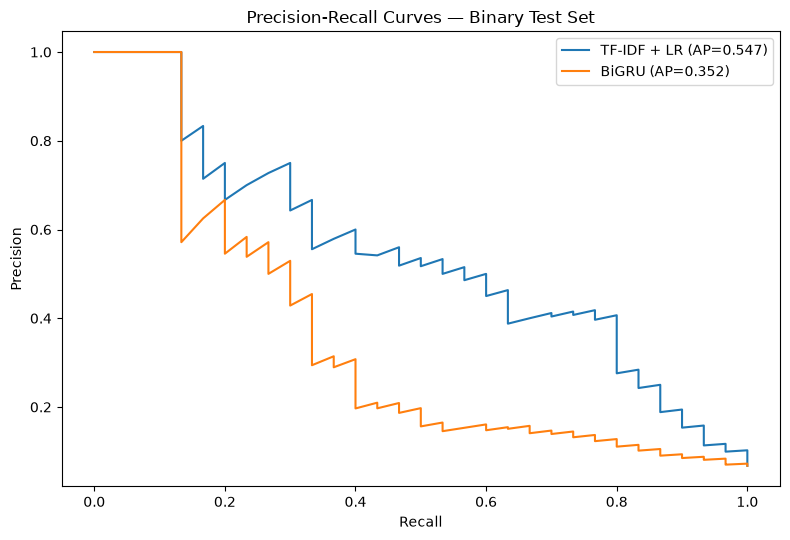

TF-IDF PR-AUC / Average Precision : 0.5471
BiGRU PR-AUC / Average Precision   : 0.3524


In [14]:
precision_tfidf, recall_tfidf, _ = precision_recall_curve(y_test, tfidf_test_proba)
precision_bigru, recall_bigru, _ = precision_recall_curve(y_test, bigru_test_proba)

pr_auc_tfidf = tfidf_test_metrics["pr_auc"]
pr_auc_bigru = bigru_test_metrics["pr_auc"]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(recall_tfidf, precision_tfidf, label=f"TF-IDF + LR (AP={pr_auc_tfidf:.3f})")
ax.plot(recall_bigru, precision_bigru, label=f"BiGRU (AP={pr_auc_bigru:.3f})")
ax.set_title("Precision-Recall Curves — Binary Test Set")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()

print(f"TF-IDF PR-AUC / Average Precision : {pr_auc_tfidf:.4f}")
print(f"BiGRU PR-AUC / Average Precision   : {pr_auc_bigru:.4f}")



## 11. Model Comparison

Model selection uses **validation Macro F1**. The test set is then used once for final reporting.

This prevents the test set from becoming a tuning set.

### Tujuan bagian ini

Bagian ini menyatukan hasil semua model ke dalam satu tabel sehingga pembaca dapat melihat performa eksperimen secara konsisten.

Model yang dibandingkan:

1. TF-IDF + Logistic Regression
2. BiLSTM baseline
3. BiGRU + Optuna

### Metrik utama

- **Validation Macro F1** → digunakan dalam proses pemilihan model.
- **Test Accuracy** → ketepatan keseluruhan.
- **Test Balanced Accuracy** → mengurangi pengaruh kelas mayoritas.
- **Test Macro F1** → rata-rata F1 antar kelas.
- **Test PR-AUC** → kualitas ranking prediksi positive.

### Cara membaca

Jangan memilih model hanya berdasarkan Accuracy. Baca beberapa metric bersama-sama, terutama Macro F1, Balanced Accuracy, dan PR-AUC.

Tabel juga diekspor ke `results/model_comparison.csv`.


,model,validation_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,test_pr_auc
0,TF-IDF + Logistic Regression,0.7578,0.9371,0.7034,0.7240,0.5471
1,BiLSTM baseline,0.6220,0.9191,0.6010,0.6186,0.2276
2,BiGRU + Optuna,0.6112,0.9393,0.5655,0.5985,0.3524


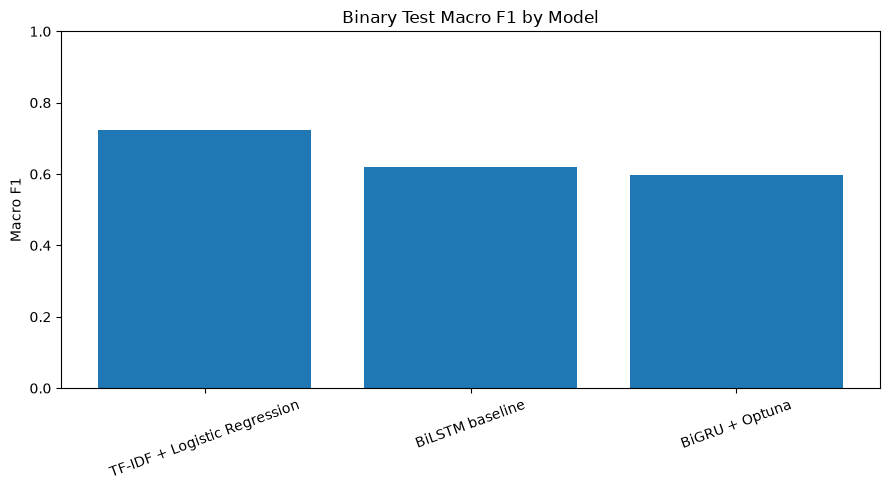

Model selected for final error analysis: TF-IDF + Logistic Regression


In [15]:
comparison = pd.DataFrame([
    {
        "model": "TF-IDF + Logistic Regression",
        "validation_macro_f1": tfidf_val_metrics["macro_f1"],
        "test_accuracy": tfidf_test_metrics["accuracy"],
        "test_balanced_accuracy": tfidf_test_metrics["balanced_accuracy"],
        "test_macro_f1": tfidf_test_metrics["macro_f1"],
        "test_pr_auc": tfidf_test_metrics["pr_auc"],
    },
    {
        "model": "BiLSTM baseline",
        "validation_macro_f1": bilstm_val_metrics["macro_f1"],
        "test_accuracy": bilstm_test_metrics["accuracy"],
        "test_balanced_accuracy": bilstm_test_metrics["balanced_accuracy"],
        "test_macro_f1": bilstm_test_metrics["macro_f1"],
        "test_pr_auc": bilstm_test_metrics["pr_auc"],
    },
    {
        "model": "BiGRU + Optuna",
        "validation_macro_f1": bigru_val_metrics["macro_f1"],
        "test_accuracy": bigru_test_metrics["accuracy"],
        "test_balanced_accuracy": bigru_test_metrics["balanced_accuracy"],
        "test_macro_f1": bigru_test_metrics["macro_f1"],
        "test_pr_auc": bigru_test_metrics["pr_auc"],
    }
])

display(comparison.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(comparison["model"], comparison["test_macro_f1"])
ax.set_title("Binary Test Macro F1 by Model")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

selected_model_name = comparison.loc[
    comparison["validation_macro_f1"].idxmax(), "model"
]
print("Model selected for final error analysis:", selected_model_name)



## 12. Error Analysis

Error analysis focuses on:
- false positives (negative comments predicted as positive)
- false negatives (positive comments predicted as negative)
- performance by comment length

The goal is not only to report a score, but to identify where the model fails.

### Tujuan bagian ini

Error analysis menjawab pertanyaan:

> **"Komentar seperti apa yang paling sering salah diprediksi model?"**

### Apa yang dilakukan kode

Kode mengumpulkan contoh prediksi yang salah dari test set dan menampilkan informasi seperti:

- teks komentar;
- label sebenarnya;
- prediksi model;
- probabilitas prediksi.

### Mengapa penting?

Kesalahan dapat berasal dari slang, typo, bahasa campuran, negasi, komentar sangat pendek, sarkasme, spam, atau konteks yang ambigu.

### Output

`results/error_analysis.csv` menjadi bahan untuk menjelaskan **failure cases** model, bukan hanya skor keberhasilan model.


In [16]:
if selected_model_name == "TF-IDF + Logistic Regression":
    selected_proba = tfidf_test_proba
    selected_threshold = tfidf_threshold
else:
    selected_proba = bigru_test_proba
    selected_threshold = bigru_threshold

selected_pred = (selected_proba >= selected_threshold).astype(int)

error_df = test_df[
    ["row_id", "comment", "published_at", "sentiment"]
].copy()
error_df["true_label"] = (error_df["sentiment"] == "positive").astype(int).values
error_df["predicted_label"] = selected_pred
error_df["positive_probability"] = selected_proba
error_df["error_type"] = np.select(
    [
        (error_df["true_label"] == 0) & (error_df["predicted_label"] == 1),
        (error_df["true_label"] == 1) & (error_df["predicted_label"] == 0),
    ],
    ["false_positive", "false_negative"],
    default="correct"
)

false_positives = error_df[error_df["error_type"] == "false_positive"].sort_values(
    "positive_probability", ascending=False
)
false_negatives = error_df[error_df["error_type"] == "false_negative"].sort_values(
    "positive_probability", ascending=True
)

print("=== FALSE POSITIVES ===")
display(false_positives[["row_id", "comment", "positive_probability"]].head(10))

print("\n=== FALSE NEGATIVES ===")
display(false_negatives[["row_id", "comment", "positive_probability"]].head(10))

error_df["token_length"] = (
    error_df["comment"]
    .fillna("")
    .map(lambda x: len(clean_for_nlp(x).split()))
)

error_df["length_bin"] = pd.cut(
    error_df["token_length"],
    bins=[-1, 3, 7, 15, 30, np.inf],
    labels=["0-3", "4-7", "8-15", "16-30", "31+"]
)

error_by_length = (
    error_df.assign(is_error=error_df["error_type"].ne("correct"))
    .groupby("length_bin", observed=False)["is_error"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "error_rate"})
    .reset_index()
)

display(error_by_length)
error_df.to_csv(RESULTS_DIR / "error_analysis.csv", index=False)



=== FALSE POSITIVES ===


,row_id,comment,positive_probability
11567,11568,ngurangin mbg❌\n ngabisin mbg✅🗿💢,0.873173
8053,8054,Aku mah waktu dulu di sekolah aku belum ada MB...,0.823122
7801,7802,Program nya bagus yang gak bagus di korupsi me...,0.821938
8974,8975,Aku setiap hari dapat \n Aku sudah dapet...,0.674369
8015,8016,Aku gak dapet mbg karna sekolahku swasta katol...,0.655871
5973,5974,Gila emang internasional d kasih mbg lebih bag...,0.635631
11541,11542,MBG buat orang ❎\nMBG buat sendiri ✅\n😱😱😱😱,0.628464
5880,5881,"Serlok sekolah internasionalnya dimana bang, b...",0.598536
8112,8113,Aku pernah dapet mbg ada belatung😢😢😢😢,0.554807
4158,4159,Orang tua larang saja anaknya menerima dan mak...,0.552082



=== FALSE NEGATIVES ===


,row_id,comment,positive_probability
4842,4843,Yg masih mendukung MBG lanjut ......hanya oran...,0.172603
11152,11153,Kak tasekakian ta makan ajah😂❤,0.200525
9932,9933,Ponakanku juga keracunan kemaren gara2 MBG ud...,0.243101
1176,1177,👍 sadar tidak sadar diakui atau tidak program ...,0.274071
7723,7724,"Maju terus MBG, agar anak indonesia cerdas , j...",0.310902
7647,7648,❤❤❤❤❤❤❤❤❤❤di Malaysia orang orang yang mengel...,0.343170
6467,6468,KASIHAN ANAK SEKOLAH ❤❤YANG SUDAH MAKAN MENIKM...,0.389089
5884,5885,Mungkin sekolah ini bayar MBG jd ya jelas ...,0.396796
8853,8854,Aku sudah hari ini mbg nya spaghetti bolognese...,0.403779
10315,10316,Program MBG baik tujuannya karena masih banyak...,0.413161


,length_bin,count,error_rate
0,0-3,31,0.032258
1,4-7,113,0.053097
2,8-15,150,0.060000
3,16-30,112,0.080357
4,31+,39,0.076923


## 13. Model Explainability

The TF-IDF + Logistic Regression baseline is directly interpretable through its coefficients:
- positive coefficient → pushes the prediction toward positive
- negative coefficient → pushes the prediction toward negative

This gives a transparent vocabulary-level explanation that can be inspected alongside the deep-learning results.

### Tujuan bagian ini

Explainability menjawab:

> **"Kata atau fitur apa yang paling terkait dengan prediksi positive dan negative?"**

### Apa yang dilakukan kode

Untuk Logistic Regression, setiap fitur TF-IDF mempunyai koefisien.

- koefisien positif → lebih terkait dengan prediksi positive;
- koefisien negatif → lebih terkait dengan prediksi negative;
- semakin besar nilai absolut koefisien, semakin kuat asosiasi linear yang dipelajari model.

### Batas interpretasi

Koefisien tidak berarti sebuah kata **menyebabkan** sentimen. Ia menunjukkan asosiasi yang dipelajari model dari dataset ini.

Hasilnya disimpan di `results/explainability_top_terms.csv`.


,feature,coefficient,direction
0,setuju mbg,5.561923,positive
1,bagus,4.481172,positive
2,mbg,3.138818,positive
3,lanjutkan,2.905424,positive
4,gak keracunan,2.796259,positive
5,setuju,2.725733,positive
6,lanjutkan mbg,2.529006,positive
7,mbg baik,2.341516,positive
8,mbg bagus,2.234199,positive
9,hh,2.087415,positive


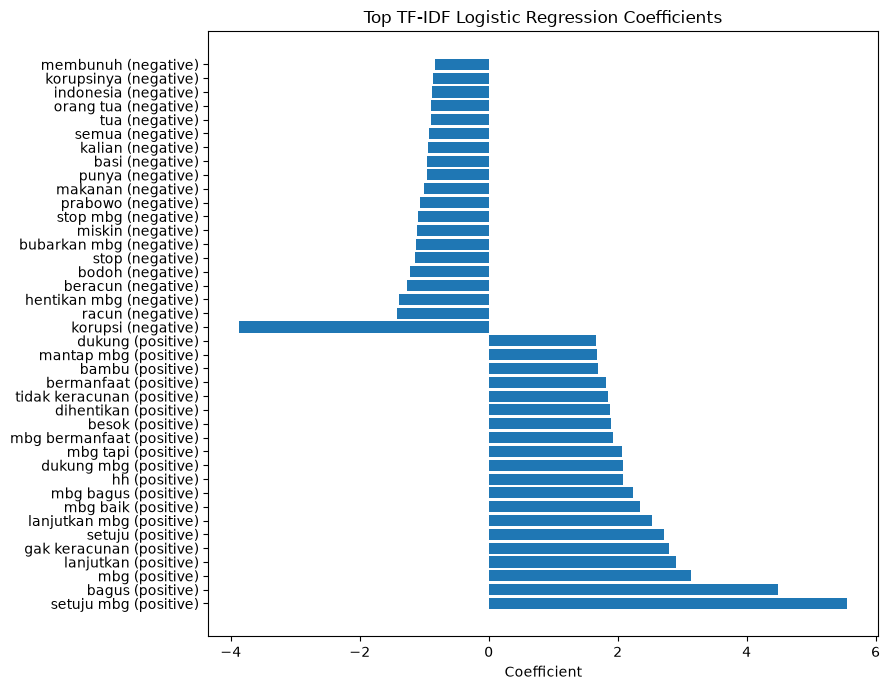

In [17]:
feature_names = np.array(tfidf.get_feature_names_out())
coef = tfidf_model.coef_[0]

top_positive_idx = np.argsort(coef)[-20:][::-1]
top_negative_idx = np.argsort(coef)[:20]

explainability_df = pd.concat([
    pd.DataFrame({
        "feature": feature_names[top_positive_idx],
        "coefficient": coef[top_positive_idx],
        "direction": "positive"
    }),
    pd.DataFrame({
        "feature": feature_names[top_negative_idx],
        "coefficient": coef[top_negative_idx],
        "direction": "negative"
    })
], ignore_index=True)

display(explainability_df)

fig, ax = plt.subplots(figsize=(9, 7))
plot_df = explainability_df.copy()
plot_df["label"] = plot_df["feature"] + " (" + plot_df["direction"] + ")"
ax.barh(plot_df["label"], plot_df["coefficient"])
ax.set_title("Top TF-IDF Logistic Regression Coefficients")
ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.show()

explainability_df.to_csv(
    RESULTS_DIR / "explainability_top_terms.csv",
    index=False,
    encoding="utf-8-sig"
)



## 14. Three-Class Classification

The binary task excludes neutral only because it is a focused polarity-detection experiment.

To keep neutral from being discarded entirely, this section trains a **3-class TF-IDF + Logistic Regression** classifier using:
- positive
- negative
- neutral

Class weighting is again applied so the large neutral class does not dominate the optimization objective.

### Tujuan bagian ini

Bagian ini kembali ke **3-class sentiment analysis**:

- positive
- negative
- neutral

Binary task hanya mempelajari positive vs negative. Bagian ini menguji kondisi ketika neutral dipertahankan sebagai kelas tersendiri.

### Apa yang dilakukan kode

TF-IDF + Logistic Regression digunakan untuk multi-class classification dengan stratified split.

Metrik:

- Accuracy
- Balanced Accuracy
- Macro F1
- Weighted F1
- Macro PR-AUC

### Cara membaca hasil

3-class task biasanya lebih sulit karena model harus membedakan tiga kategori.

**Jangan menyamakan angka binary dengan 3-class secara langsung** karena ruang label dan tingkat kesulitannya berbeda.

Hasil disimpan di `results/three_class_metrics.csv`.


3-class metrics:


,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_pr_auc
0,0.832416,0.678443,0.657282,0.8346,0.702344



3-class classification report:


,precision,recall,f1-score,support
negative,0.701878,0.720482,0.711058,415.000000
neutral,0.897348,0.881513,0.889360,1190.000000
positive,0.325000,0.433333,0.371429,30.000000
accuracy,0.832416,0.832416,0.832416,0.832416
macro avg,0.641409,0.678443,0.657282,1635.000000
weighted avg,0.837232,0.832416,0.834600,1635.000000


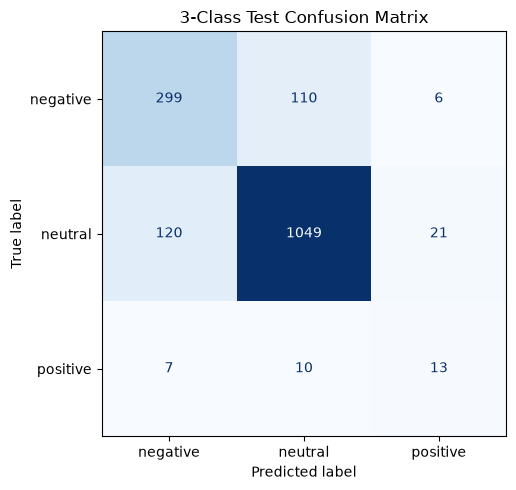

In [18]:
three_df = model_df[
    model_df["sentiment"].isin(VALID_LABELS)
    & model_df["text_preprocessed"].ne("")
].copy()

train3, test3 = train_test_split(
    three_df,
    test_size=0.15,
    random_state=SEED,
    stratify=three_df["sentiment"]
)
train3, val3 = train_test_split(
    train3,
    test_size=0.1764705882,
    random_state=SEED,
    stratify=train3["sentiment"]
)

# Assert no normalized-text overlap across the 3-class splits as well.
assert_no_duplicate_overlap(train3, val3, test3)

vectorizer3 = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    max_features=30000
)

X3_train = vectorizer3.fit_transform(train3["text_preprocessed"])
X3_val = vectorizer3.transform(val3["text_preprocessed"])
X3_test = vectorizer3.transform(test3["text_preprocessed"])

three_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=SEED
)
three_model.fit(X3_train, train3["sentiment"])

three_val_pred = three_model.predict(X3_val)
three_test_pred = three_model.predict(X3_test)
three_test_proba = three_model.predict_proba(X3_test)
three_classes = three_model.classes_

three_metrics = {
    "accuracy": accuracy_score(test3["sentiment"], three_test_pred),
    "balanced_accuracy": balanced_accuracy_score(test3["sentiment"], three_test_pred),
    "macro_f1": f1_score(test3["sentiment"], three_test_pred, average="macro", zero_division=0),
    "weighted_f1": f1_score(test3["sentiment"], three_test_pred, average="weighted", zero_division=0),
    "macro_pr_auc": average_precision_score(
        label_binarize(test3["sentiment"], classes=three_classes),
        three_test_proba,
        average="macro"
    )
}

print("3-class metrics:")
display(pd.DataFrame([three_metrics]))

print("\n3-class classification report:")
display(pd.DataFrame(
    classification_report(
        test3["sentiment"],
        three_test_pred,
        labels=list(three_classes),
        output_dict=True,
        zero_division=0
    )
).T)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    test3["sentiment"],
    three_test_pred,
    labels=list(three_classes),
    display_labels=list(three_classes),
    cmap="Blues",
    colorbar=False,
    ax=ax
)
ax.set_title("3-Class Test Confusion Matrix")
plt.tight_layout()
plt.show()



## 15. Training Curves

Training and validation curves are included to make deep-learning behavior visible and to help identify overfitting/underfitting patterns.

### Tujuan bagian ini

Training curves digunakan untuk memahami **proses belajar model deep learning**, bukan hanya hasil akhirnya.

Grafik yang dibuat:

1. Training vs Validation Accuracy
2. Training vs Validation Loss

### Cara membaca

- Training dan validation sama-sama membaik → model masih belajar dengan baik.
- Training membaik tetapi validation berhenti membaik → perlu dicermati.
- Training loss terus turun tetapi validation loss naik → pola yang konsisten dengan overfitting.

Grafik ini memberi konteks mengenai perilaku model selama epoch, sedangkan metric pada test set tetap digunakan sebagai evaluasi akhir.


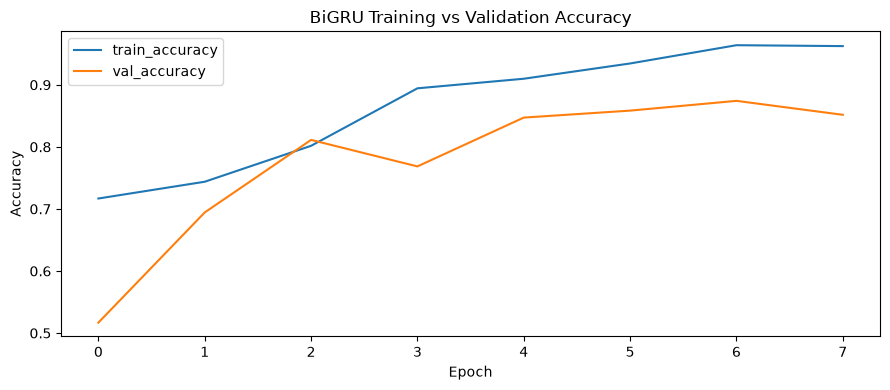

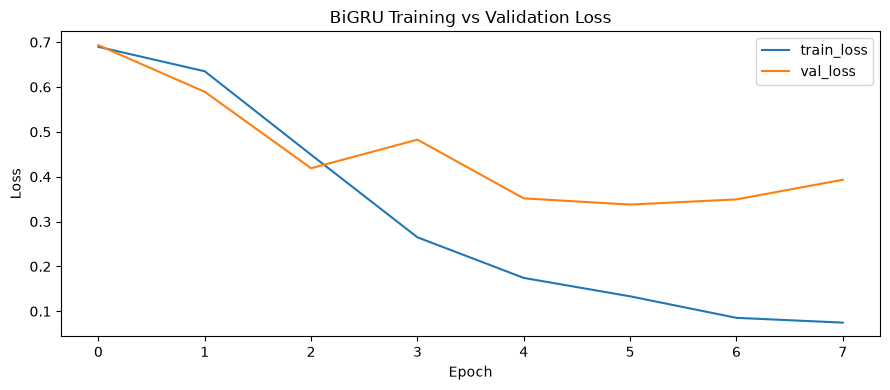

In [19]:
history_df = pd.DataFrame(final_bigru_history.history)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history_df["accuracy"], label="train_accuracy")
ax.plot(history_df["val_accuracy"], label="val_accuracy")
ax.set_title("BiGRU Training vs Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history_df["loss"], label="train_loss")
ax.plot(history_df["val_loss"], label="val_loss")
ax.set_title("BiGRU Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()



## 16. Final Results & Portfolio Summary

### Tujuan bagian ini

Ini adalah **ringkasan akhir eksperimen**. Hasil penting dari berbagai section dikumpulkan agar pembaca tidak perlu mencari metric satu per satu.

### Yang diringkas

- jumlah dataset awal;
- jumlah data setelah duplicate-leakage control;
- jumlah data untuk binary modeling;
- status validation review;
- status dan jumlah trial Optuna;
- model yang dipakai dalam analisis;
- tabel perbandingan performa.

### Cara membaca

Bagian ini berfungsi seperti **technical executive summary**:

`12,000 raw rows → 10,934 unique model rows → 2,963 binary rows`

Kemudian pembaca dapat melihat hasil performa model pada satu tabel.

Output juga disimpan ke `results/project_summary.json`.


In [20]:
binary_reports = {
    "TF-IDF + Logistic Regression": tfidf_test_metrics,
    "BiLSTM baseline": bilstm_test_metrics,
    "BiGRU + Optuna": bigru_test_metrics,
}

summary = {
    "dataset": {
        "raw_rows": int(len(YT_comments)),
        "model_rows_after_dedup": int(len(model_df)),
        "binary_rows": int(len(binary_df)),
        "sentiment_counts": {
            label: int(sentiment_counts[label]) for label in VALID_LABELS
        },
    },
    "data_quality": quality,
    "human_validation_status": human_validation_status,
    "human_validation_label_space": VALIDATION_LABELS,
    "human_validation_note": (
        "Reviewed AI-assisted binary labels; neutral from the 3-class dataset "
        "is mapped to negative. This is not an independent gold-standard annotation study."
    ),
    "optuna": {
        "requested": RUN_OPTUNA,
        "executed": optuna_ran,
        "completed_trials": int(optuna_completed_trials),
        "best_params": best_bigru_params,
    },
    "binary_models": {
        name: {k: float(v) for k, v in metrics.items()}
        for name, metrics in binary_reports.items()
    },
    "selected_model_for_error_analysis": selected_model_name,
    "three_class": {k: float(v) for k, v in three_metrics.items()},
}

model_comparison_export = comparison.copy()
model_comparison_export.to_csv(
    RESULTS_DIR / "model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

pd.DataFrame([tfidf_test_metrics]).to_csv(
    RESULTS_DIR / "tfidf_binary_metrics.csv",
    index=False
)
pd.DataFrame([bilstm_test_metrics]).to_csv(
    RESULTS_DIR / "bilstm_binary_metrics.csv",
    index=False
)
pd.DataFrame([bigru_test_metrics]).to_csv(
    RESULTS_DIR / "bigru_binary_metrics.csv",
    index=False
)
pd.DataFrame([three_metrics]).to_csv(
    RESULTS_DIR / "three_class_metrics.csv",
    index=False
)

with open(RESULTS_DIR / "project_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("=== PORTFOLIO SUMMARY ===")
print(f"Dataset rows                : {len(YT_comments):,}")
print(f"Unique model rows           : {len(model_df):,}")
print(f"Human review status         : {human_validation_status}")
print(f"Optuna executed             : {optuna_ran}")
print(f"Optuna trials completed     : {optuna_completed_trials}")
print(f"Selected model (validation) : {selected_model_name}")

display(
    comparison[
        [
            "model",
            "validation_macro_f1",
            "test_accuracy",
            "test_balanced_accuracy",
            "test_macro_f1",
            "test_pr_auc",
        ]
    ].round(4)
)


=== PORTFOLIO SUMMARY ===
Dataset rows                : 12,000
Unique model rows           : 10,934
Human review status         : COMPLETED_REVIEWED
Optuna executed             : True
Optuna trials completed     : 5
Selected model (validation) : TF-IDF + Logistic Regression


,model,validation_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,test_pr_auc
0,TF-IDF + Logistic Regression,0.7578,0.9371,0.7034,0.7240,0.5471
1,BiLSTM baseline,0.6220,0.9191,0.6010,0.6186,0.2276
2,BiGRU + Optuna,0.6112,0.9393,0.5655,0.5985,0.3524


## 17. Interpretation & Limitations

### What the project demonstrates
- Data quality checks are separated from modeling.
- Duplicate comments are controlled **before** splitting to prevent text leakage.
- The binary task uses a documented `positive` vs `negative` label space.
- The project owner reviewed the validation sample under the same binary rule.
- Class imbalance is handled with class weighting and evaluated with Macro F1, Balanced Accuracy, and PR-AUC.
- Optuna tuning optimizes validation Macro F1 and never uses the test set.
- Error analysis and model explainability are part of the modeling workflow.
- Neutral is retained in the dataset and evaluated through a dedicated 3-class benchmark.

### Remaining methodological boundary

The portfolio dataset still contains AI-assisted labels. The completed review is therefore **human-reviewed AI-assisted annotation**, not an independent gold-standard label study.

The dataset is a YouTube sample and may include slang, sarcasm, typo, spam, duplicated phrasing, and context that is difficult to infer from a single comment. Trends describe the collected comments and do not establish causality or population-wide sentiment.

### Tujuan bagian ini

Bagian ini menjawab **"Apa yang dapat disimpulkan dari project ini, dan apa batasannya?"**

### Yang dapat didukung

- kondisi dan distribusi dataset;
- performa model pada split yang digunakan;
- jenis error model;
- kata/fitur yang terkait dengan prediksi;
- perbedaan hasil binary dan 3-class benchmark.

### Batasan penting

1. Dataset adalah sample komentar YouTube.
2. Label dataset menggunakan AI-assisted labeling.
3. Komentar dapat mengandung slang, typo, spam, sarkasme, atau konteks yang sulit dipahami dari satu komentar.
4. Performa model berlaku untuk dataset dan split project ini; tidak otomatis berlaku untuk seluruh komentar publik.
5. Association antara kata dan label bukan bukti sebab-akibat.

Bagian ini memastikan hasil portfolio tetap transparan dan tidak melebih-lebihkan apa yang sebenarnya diukur notebook.


## 18. Reproducibility Checklist

- Fixed random seed: `42`
- Train/validation/test split uses stratification.
- TF-IDF vectorizers are fitted on training data only.
- Neural tokenizer is fitted on training data only.
- Duplicate normalized text is removed before modeling.
- Conflicting duplicate-label groups are excluded from the ML corpus.
- Class weights are derived from the training set.
- Hyperparameter tuning uses validation Macro F1 only.
- Test data is held out for final evaluation.
- PR-AUC is reported for imbalanced binary classification.
- Binary human-review file uses only `positive` and `negative`.
- Original `neutral` labels are mapped to `negative` only for the binary review, while the 3-class benchmark remains unchanged.
- Result tables and JSON summary are exported to `results/`.

### Tujuan bagian ini

Checklist ini menunjukkan bagaimana eksperimen dijaga agar **reproducible** dan evaluasinya tetap fair.

### Hal yang dikontrol

- random seed;
- stratified split;
- vectorizer/tokenizer hanya belajar dari training data;
- duplicate text dikontrol sebelum split;
- conflicting duplicate-label groups dikeluarkan;
- class weights berasal dari training set;
- Optuna menggunakan validation Macro F1;
- test set ditahan untuk evaluasi akhir;
- PR-AUC dilaporkan untuk binary imbalance;
- hasil diekspor ke `results/`.

### Cara menggunakan checklist ini

Reviewer dapat menggunakannya sebagai **audit trail sederhana** untuk mengecek apakah ada risiko data leakage atau komponen eksperimen yang tidak terdokumentasi.


## 19. Portfolio Conclusion

This project presents an end-to-end **Text Mining + NLP + Machine Learning + Deep Learning** workflow for YouTube comments related to MBG.

The final pipeline goes beyond model training: it includes data-quality auditing, duplicate-leakage prevention, reviewed binary label validation, imbalance-aware evaluation, Optuna tuning, PR-AUC, error analysis, explainability, and a 3-class benchmark.

The notebook intentionally distinguishes **what is measured from the collected dataset**, **what was reviewed by the project owner**, and **what cannot be claimed as an independent gold-standard result**.

### Kesimpulan project dalam bahasa sederhana

Project ini membangun pipeline lengkap untuk **mengubah komentar YouTube menjadi data teks yang dapat dianalisis dan dimodelkan**.

Nilai utama project bukan hanya membuat model, tetapi menunjukkan seluruh proses:

**data dikumpulkan → kualitas data diperiksa → duplikat dikontrol → teks diproses → pola dieksplorasi → beberapa model dibandingkan → hyperparameter dituning → performa diuji → error dianalisis → model dijelaskan → hasil disimpan.**

Dengan struktur ini, pembaca dapat memahami bukan hanya **apa yang dilakukan oleh kode**, tetapi juga **mengapa setiap langkah diperlukan dan bagaimana output satu tahap digunakan pada tahap berikutnya**.

> **Key takeaway:** notebook ini merupakan dokumentasi end-to-end workflow Text Mining + NLP + Machine Learning + Deep Learning, bukan sekadar kumpulan skor model.
